# To be completed at the Data Science Workshop and in your own time.

These set of examples we will help you get familiar with Jupyter notebooks and useful Python packages and terminology - this is important not only for practice required for the assessements, but also to go through some of the basic concepts that will be needed to understand how to do data science, using Python and Jupyter Notebooks as our tools.

Before attempting these examples, please ensure you have read through [Chapter 1 Jupyter Notebook](https://github.com/itrharrison/PX4146/blob/main/Chapter1/Chapter1.ipynb) and have completed the Learning Central **Chapter 1 quiz**.

First we will define some useful packages we want to use in this notebook to answer the following questions:

In [3]:
# define and import some important things
import numpy as np
import pylab as plt

%matplotlib inline

***


# Plotting in Python

## Question

A star brightens over time until it explodes as a supernova. Astronomers record the brightness (as a factor of the normal brightness) with days since it started to brighten, recording the following datasets: <br><br>

time = [0.,0.08163265,    0.24489796,  0.32653061,  
  0.48979592,   0.73469388,  0.81632653,  
  0.97959184 ,  1.2244898 ,  1.30612245,  
  1.46938776  ,1.71428571,  1.79591837,
  1.95918367 ,   2.20408163,  2.28571429,  
  2.44897959 ,    2.7755102,
  2.93877551 ,  3.18367347 , 3.26530612  ,
  3.42857143 , 3.67346939,  3.75510204   , 4.       ]
<br><br>

brightness = [0.36253211,    1.16748232 ,
  1.78775018,  2.01934344 ,   2.70657393 ,
  2.57897185,  2.96562829 ,    3.00174824 ,
  2.93663326,  2.80591525 ,   2.11027035 ,
  1.67940753,  1.64772549 ,  0.3513817  ,
  0.33366962,  0.47097419 , -0.39790443,
 -0.65133529, -1.52086508 , -1.76831912,
 -2.05865798, -1.55083722 ,-1.90755375 ,
 -1.74307249, -1.66250842]

<br>

Day 0 marks the time of the explosion.
<br>

1. Plot the data. Don't forget to label the axes. Set the colour of the data to be green with a diamond marker. <br><br>

2. The brightness values have an estimated error of 10%.  Plot the datapoints with errorbars in $y$.   <br><br>

3. Astronomer Rees argues that this data could be fit by the function $y =  Asin(Bx)+C$. Plot this function on top of your data with some guesses at what $A$, $B$ and $C$ are (hint: $C=0.5$ provides a good fit to the data).<br><br>

4. Discuss the plot.

### Answer:

*Your answer here:*

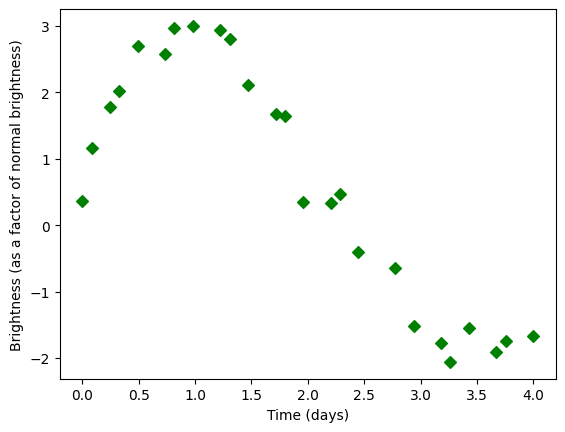

In [4]:
#question 1

time = [0.,0.08163265,    0.24489796,  0.32653061,
  0.48979592,   0.73469388,  0.81632653,
  0.97959184 ,  1.2244898 ,  1.30612245,
  1.46938776  ,1.71428571,  1.79591837,
  1.95918367 ,   2.20408163,  2.28571429,
  2.44897959 ,    2.7755102,
  2.93877551 ,  3.18367347 , 3.26530612  ,
  3.42857143 , 3.67346939,  3.75510204   , 4.       ]

brightness = [0.36253211,    1.16748232 ,
  1.78775018,  2.01934344 ,   2.70657393 ,
  2.57897185,  2.96562829 ,    3.00174824 ,
  2.93663326,  2.80591525 ,   2.11027035 ,
  1.67940753,  1.64772549 ,  0.3513817  ,
  0.33366962,  0.47097419 , -0.39790443,
 -0.65133529, -1.52086508 , -1.76831912,
 -2.05865798, -1.55083722 ,-1.90755375 ,
 -1.74307249, -1.66250842]

 #question1 plot the data
fig,ax = plt.subplots()
ax.scatter(time,brightness, color="green", marker = "D")
ax.set(xlabel="Time (days)")
ax.set(ylabel="Brightness (as a factor of normal brightness)")
plt.show()

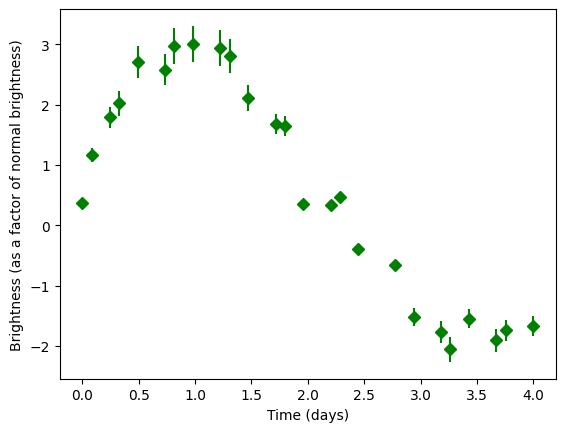

In [7]:
#question 2
#same as above but applying 10% error bars
brightness = np.array(brightness)
bright_errors = np.abs(brightness*0.1)

fig,ax = plt.subplots()
#ax.scatter(time,brightness, color="green", marker = "D", )

ax.errorbar(time, brightness, yerr=bright_errors, fmt='D', label='Data with Errorbars', color = "green")

ax.set(xlabel="Time (days)")
ax.set(ylabel="Brightness (as a factor of normal brightness)")
plt.show()

Fitted paramaters A: 1.7397349382465925  B: 1.4283541127969586  C: 0.2836291954301714


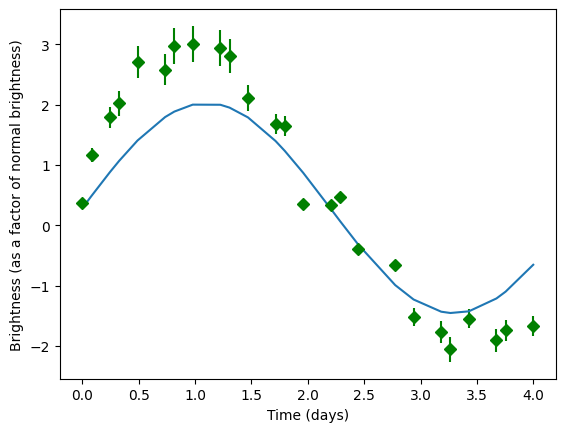

In [29]:
#question 3
from scipy.optimize import curve_fit #use this to make guesses and get a good fit
def fit_function(x,A,B,C):  #x is the time, y is the output from the theory,
  #C = 0.5 # lets see if I can reproduce 0.5 from fitting
  A = np.array(A)
  B = np.array(B)
  C = np.array(C)
  return A*np.sin(B*x)+C

param, param_cov = curve_fit(fit_function, xdata=time, ydata=brightness, sigma = bright_errors)
print("Fitted paramaters A:", param[0]," B:", param[1]," C:", param[2])
#print(param_cov)

#modeled_brightness = param[0] * np.sin(param[1] * time)
modeled_brightness = fit_function(time, param[0], param[1],param[2])
#print(modeled_brightness)
fig,ax = plt.subplots()
#ax.scatter(time,brightness, color="green", marker = "D", )

ax.errorbar(time, brightness, yerr=bright_errors, fmt='D', label='Data with Errorbars', color = "green")
plt.plot(time,modeled_brightness)

ax.set(xlabel="Time (days)")
ax.set(ylabel="Brightness (as a factor of normal brightness)")
plt.show()

question 4
The fit for the plot here is not that good. The amplitude of the modeled data is too low compared to the actuall data and as a result the model does not pass throguh most of the data or error bars. However the period of the sine wave does appear to match the data quite well.
The data itself indicates that the brighness changes from minimum to maximum about every 3 days. Additionally the error bar method of taking 10% of the measured value may be particually limited and not repreentative when the observed brightness is close to zero, the implication of the tool being so precise may not be accurate.

 # Conditional Statements

## Question

You are driving too fast and a police officer stops you. Write a **function** to return one of 3 possible results: "No ticket", "Small ticket", or "Big Ticket". If your speed is 70mph or less, the result is "No Ticket". If speed is between 71 and 80mph inclusive, the result is "Small Ticket". If speed is 81mph or more, the result is "Big Ticket". Unless it is your birthday -- on your birthday, the police officer will let you go at 5mph higher in all cases.
<br>

Tip: For your birthday, use True and False statements.
<br>

Demonstrate your code works using print statements.

### Answer:

*Your answer here:*